# <font color="blue"> Taller: Detección de anomalías cardiacas </font>
##Descripción general

En este ejemplo, entrenará un codificador automático para detectar anomalías en el conjunto de datos ECG5000 . Este conjunto de datos contiene 5000 electrocardiogramas , cada uno con 140 puntos de datos. Utilizará una versión simplificada del conjunto de datos, donde cada ejemplo se ha etiquetado como 0 (correspondiente a un ritmo anormal) o 1 (correspondiente a un ritmo normal). Le interesa identificar los ritmos anormales.

Nota: este es un conjunto de datos etiquetado, por lo que podría expresarlo como un problema de aprendizaje supervisado. El objetivo de este ejemplo es ilustrar los conceptos de detección de anomalías que puede aplicar a conjuntos de datos más grandes, donde no tiene etiquetas disponibles (por ejemplo, si tiene muchos miles de ritmos normales y solo una pequeña cantidad de ritmos anormales).
¿Cómo detectará anomalías utilizando un codificador automático? Recuerde que un codificador automático está entrenado para minimizar el error de reconstrucción. Entrenará un codificador automático solo en los ritmos normales, luego lo usará para reconstruir todos los datos. Nuestra hipótesis es que los ritmos anormales tendrán mayor error de reconstrucción. A continuación, clasificará un ritmo como anomalía si el error de reconstrucción supera un umbral fijo.

Cargar datos de ECG



El objetivo de este taller es entrenar un autoencoder que sea capaz de detectar la presencia o ausencia de irregularidades en el ritmo cardiaco, a partir de señales ECG. En el caso de la presencia de alguna anomalía clasificaremos al sujeto como “anormal” o de lo contrario lo clasificaremos como “normal”.

El reto en este caso es que “a simple vista”, es decir inspeccionando la señal ECG, no resulta fácil determinar si el sujeto es normal o anormal:


![](https://github.com/adiacla/bigdata/blob/master/ecg-normal-anormal-deteccion-anomalias.png?raw=true)
}

El conjunto de datos fue tomado de timeseriesclassification.com

### Cargar datos de ECG


El conjunto de datos que utilizará se basa en uno de timeseriesclassification.com.


In [1]:
import pandas as pd # Importamos la biblipoteca pandas
# Bajamos el dataset
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,0.608558,-0.335651,-0.990948,-1.784153,-2.626145,-2.957065,-2.931897,-2.664816,-2.090137,-1.461841,...,1.757705,2.291923,2.704595,2.451519,2.017396,1.704358,1.688542,1.629593,1.342651,0.0
4994,-2.060402,-2.860116,-3.405074,-3.748719,-3.513561,-3.006545,-2.234850,-1.593270,-1.075279,-0.976047,...,1.388947,2.079675,2.433375,2.159484,1.819747,1.534767,1.696818,1.483832,1.047612,0.0
4995,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,-0.645363,...,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334,0.0
4996,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,-1.374321,...,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932,0.0


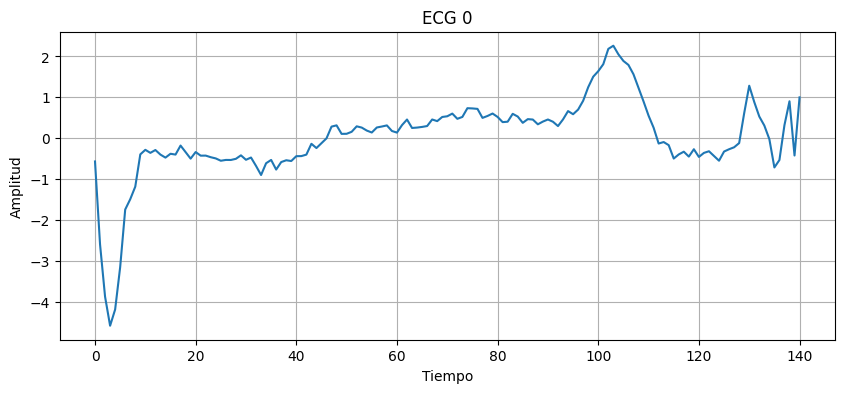

In [2]:
import matplotlib.pyplot as plt

# Mostrar solo la primera señal (primera fila)
plt.figure(figsize=(10, 4))
plt.plot(dataframe.iloc[2, :])  # Toma los primeros 140 datos de la primera fila
plt.title("ECG 0")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


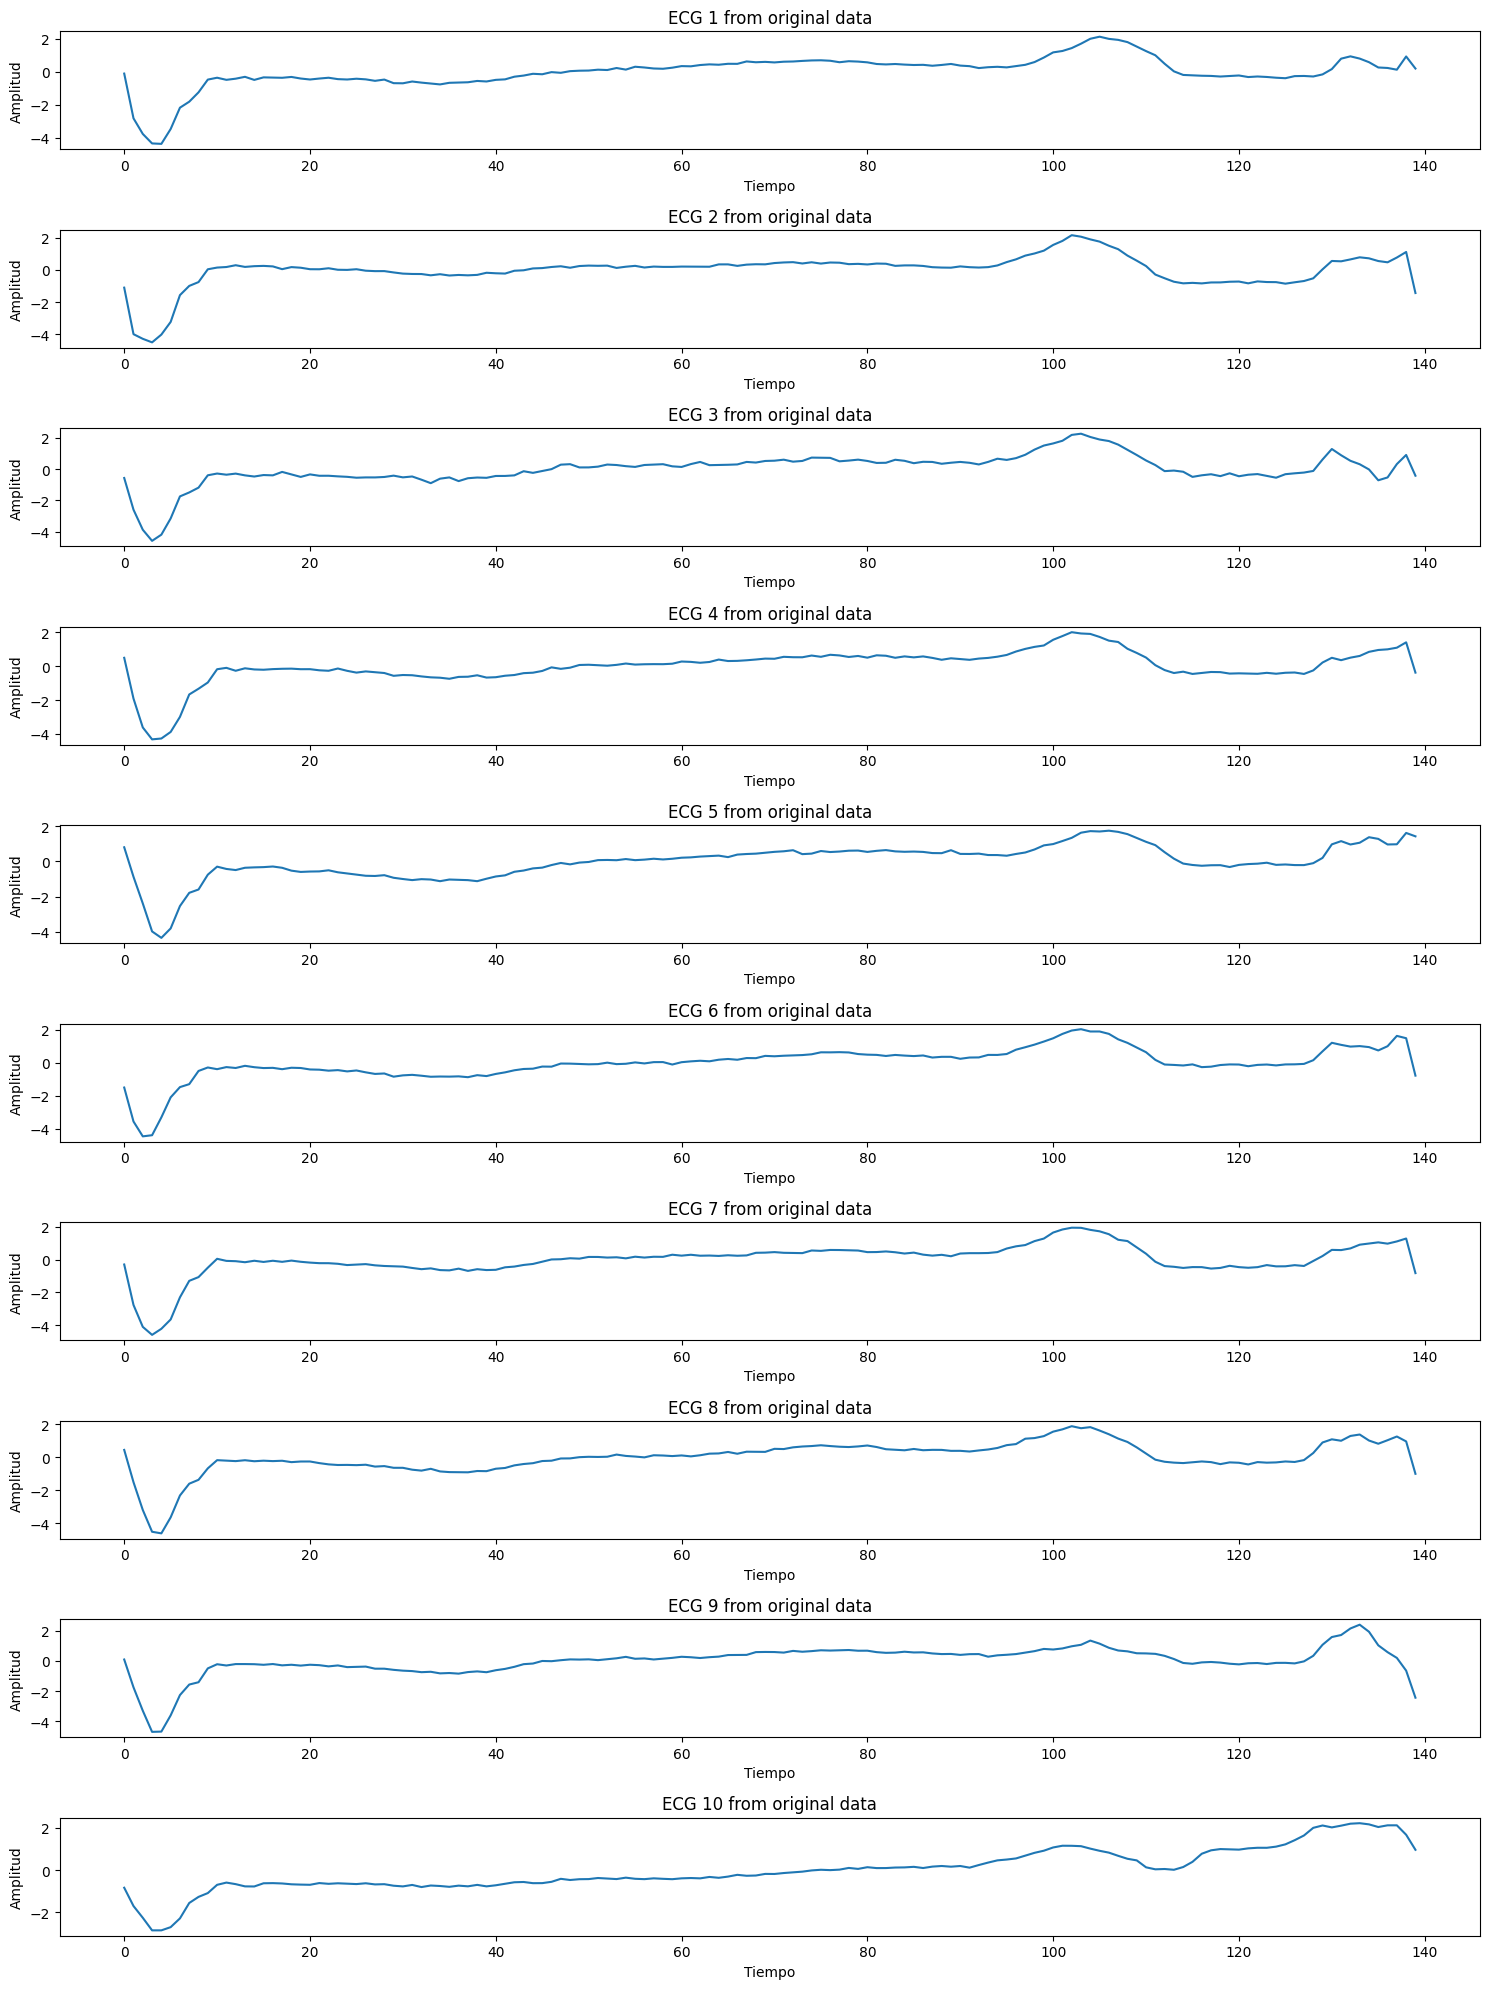

In [3]:
import matplotlib.pyplot as plt

num_images = 10

# Create a figure and axes for the subplots with one image per row
# Adjust figsize to occupy full width and provide sufficient height for all plots
fig, axes = plt.subplots(num_images, 1, figsize=(15, num_images * 2))

# Iterate over the images and plot them
for i in range(num_images):
    # Plot the i-th ECG signal (row) from the dataframe, excluding the last column (label)
    axes[i].plot(dataframe.iloc[i, :-1])
    axes[i].set_title(f"ECG {i+1} from original data")  # Set title for the subplot, starting from 1
    axes[i].set_xlabel("Tiempo")  # Set x-axis label
    axes[i].set_ylabel("Amplitud") # Set y-axis label

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [4]:
dataframe.iloc[:,-1:].value_counts()

,count
140,
1.0,2919
0.0,2079


In [5]:
from sklearn.model_selection import train_test_split # Import the train_test_split function

# La última columna contiene las etiquetas (por ejemplo: normal o anómalo)
labels = raw_data[:, -1]

# Todas las demás columnas son los datos del electrocardiograma
data = raw_data[:, 0:-1]


train_data, test_data, train_labels, test_labels =train_test_split(data, labels, test_size=0.2, random_state=21, stratify=labels)


type(data)

numpy.ndarray

In [6]:
!pip list | grep tensorflow

tensorflow                               2.20.0
tensorflow-datasets                      4.9.9
tensorflow-hub                           0.16.1
tensorflow-metadata                      1.17.3
tensorflow-probability                   0.25.0
tensorflow-text                          2.20.1


Normalice los datos a [0,1] .


In [7]:
import tensorflow as tf # Importamos la librería tensorflow y la llamamos 'tf'

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Ajustar solo sobre los datos de entrenamiento
train_data = scaler.fit_transform(train_data)

# Usar los mismos parámetros para escalar los datos de prueba
test_data = scaler.transform(test_data)

# Convertir a float32 si vas a usar TensorFlow después
train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

type(train_data)

tensorflow.python.framework.ops.EagerTensor

Entrenará el codificador automático usando solo los ritmos normales, que están etiquetados en este conjunto de datos como 1 . Separar los ritmos normales de los ritmos anormales.

In [8]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels] #Filtro los datos de EGC Normal para entrenamiento
normal_test_data = test_data[test_labels] #Filtro los datos de EGC Normal para validación

anomalous_train_data = train_data[~train_labels] #Filtro los datos de EGC Anormal para entrenamiento
anomalous_test_data = test_data[~test_labels] #Filtro los datos de EGC Anormal para validación

In [9]:
len(normal_train_data), len(anomalous_train_data)

(2335, 1663)

In [10]:
len(normal_test_data), len(anomalous_test_data)

(584, 416)

Trazar un ECG normal.

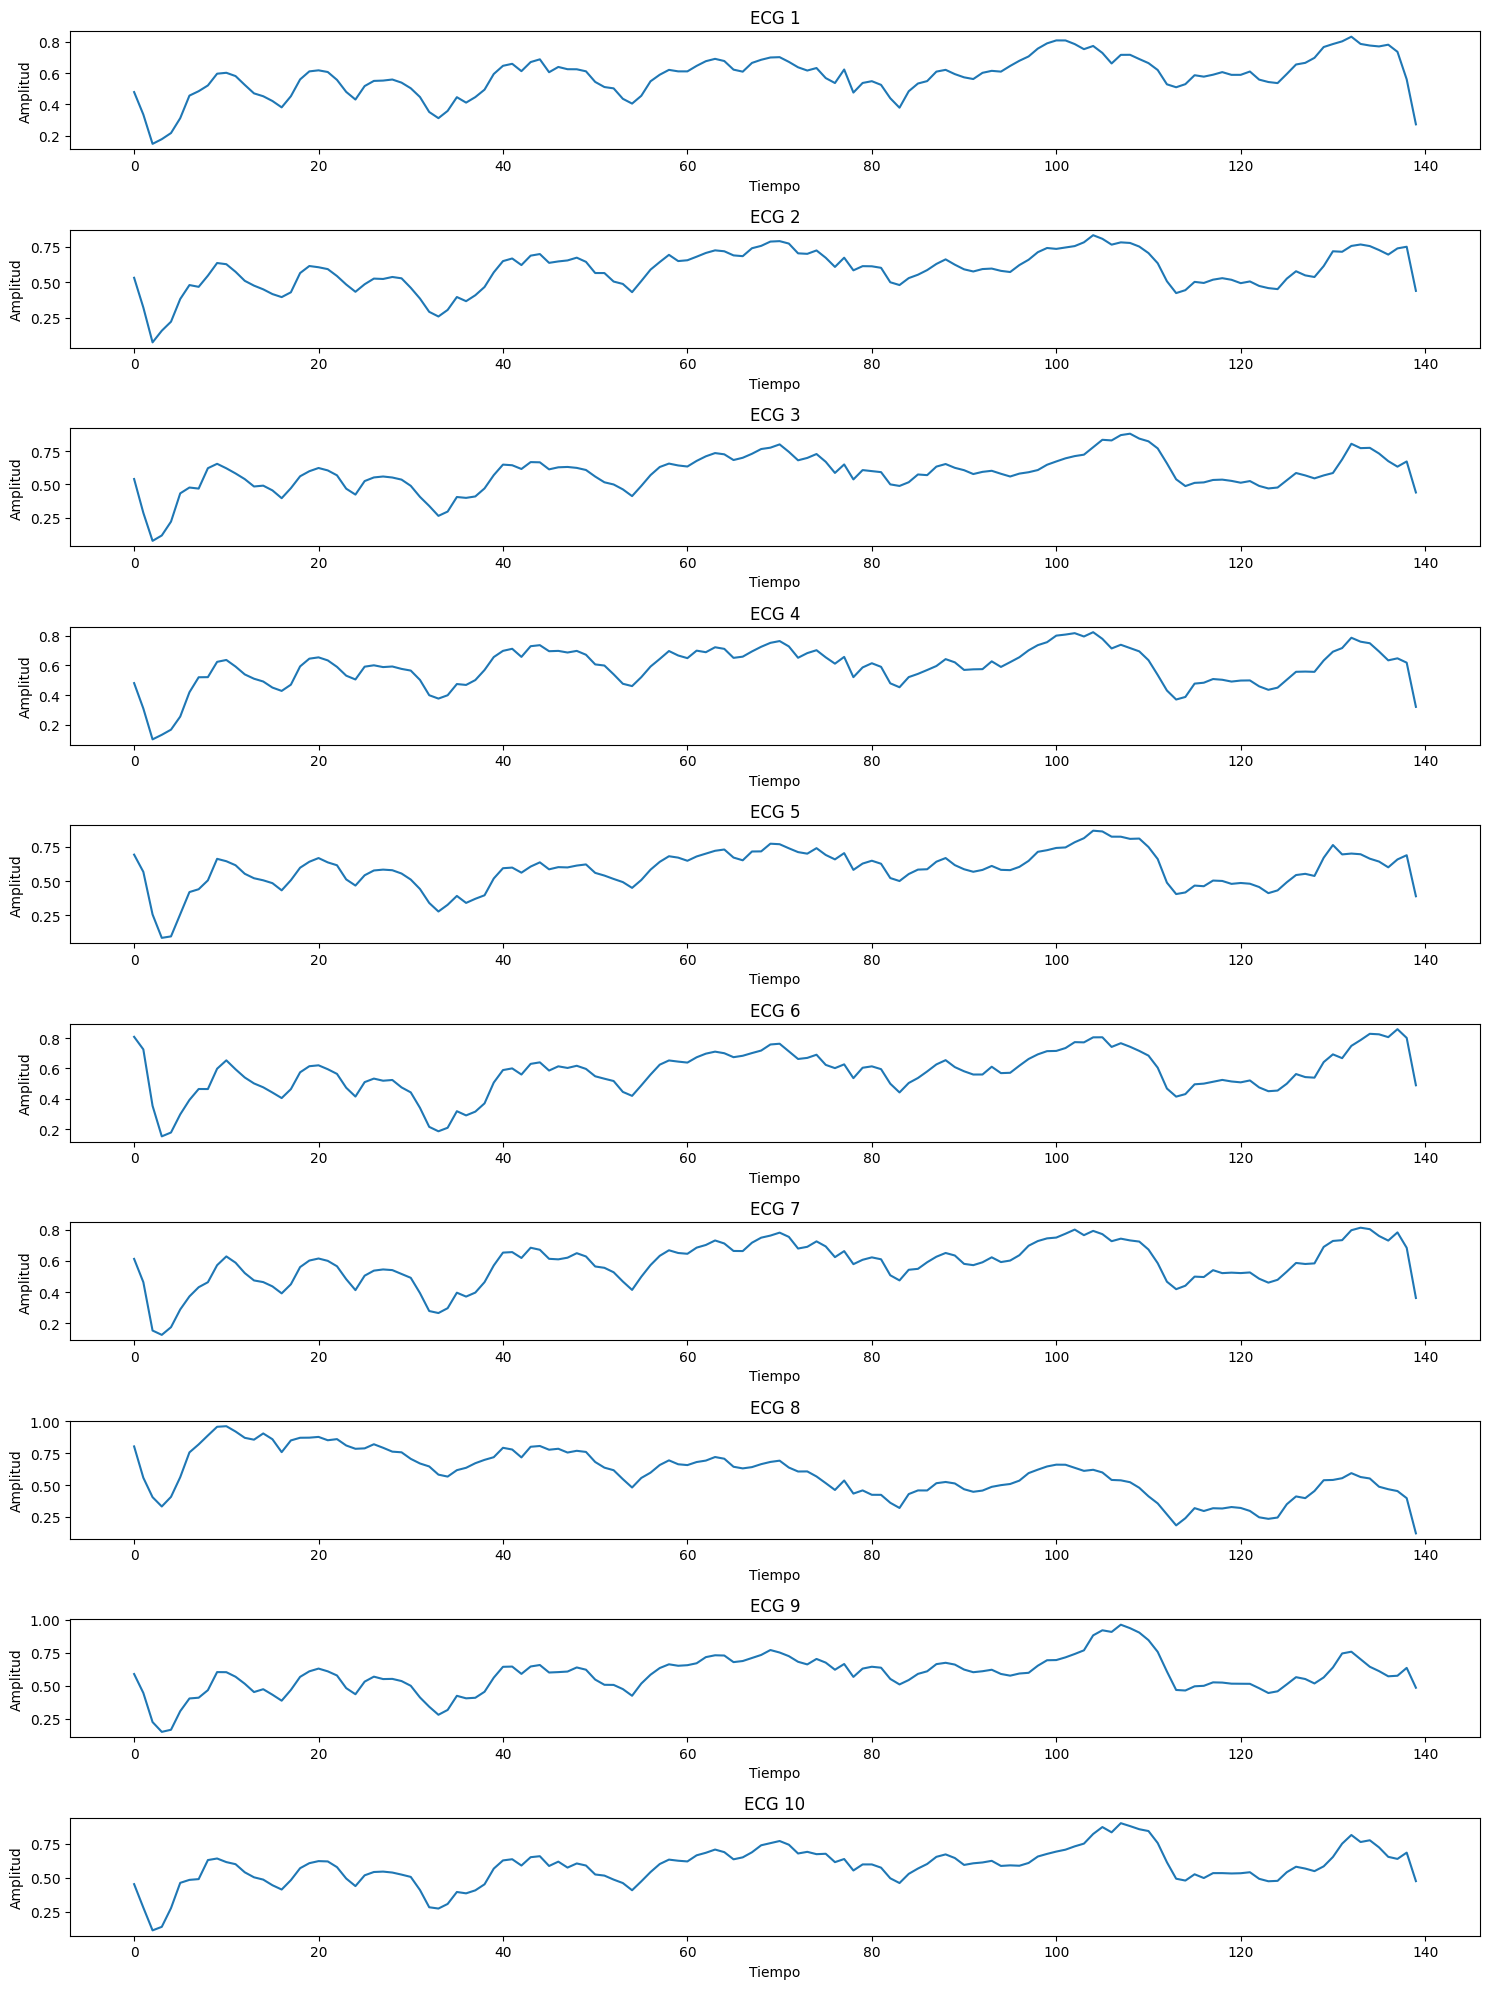

In [11]:
# Generar 10 imágenes Normales, una por fila y ocupando todo el ancho de la pantalla

import matplotlib.pyplot as plt

# Number of images to generate
num_images = 10

# Create a figure and axes for the subplots with one image per row
# Adjust figsize to occupy full width and provide sufficient height for all plots
fig, axes = plt.subplots(num_images, 1, figsize=(15, num_images * 2)) # 15 for width, num_images*2 for height

# Iterate over the images and plot them
for i in range(num_images):
    # Plot the ECG data for the current subplot
    axes[i].plot(normal_train_data[i])  # Assuming normal_train_data contains ECG data
    axes[i].set_title(f"ECG {i+1}")  # Set title for the subplot
    axes[i].set_xlabel("Tiempo")  # Set x-axis label
    axes[i].set_ylabel("Amplitud") # Set y-axis label

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


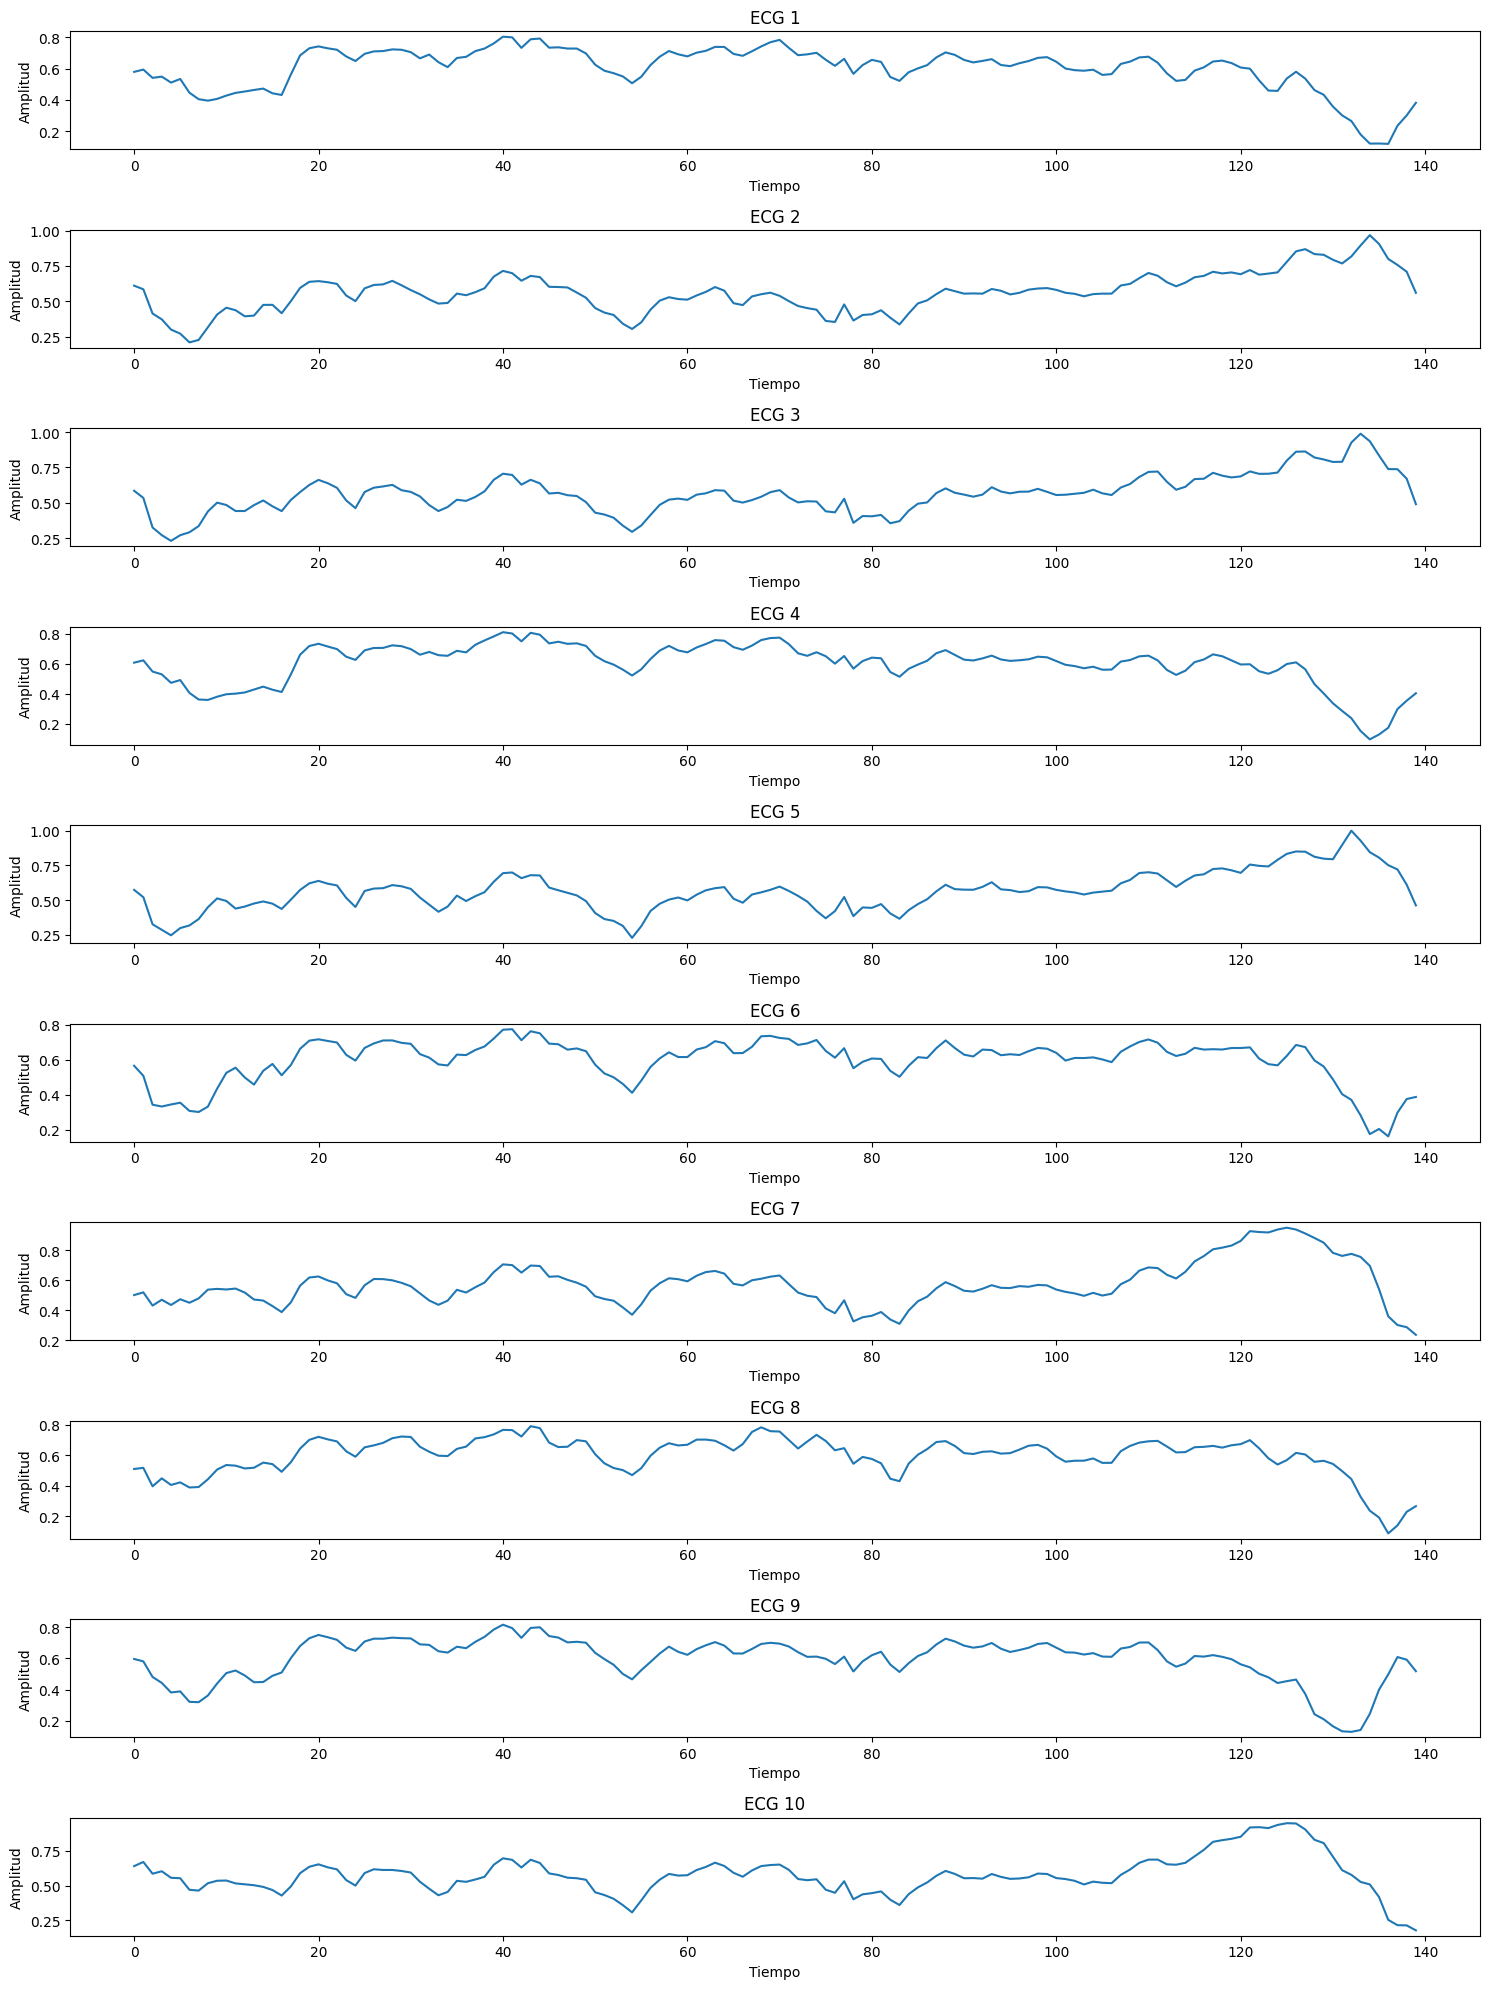

In [12]:
#Generar 10 imagenes Anormales, una por fila y ocupando todo el ancho de la pantalla

import matplotlib.pyplot as plt

# Number of images to generate
num_images = 10

# Create a figure and axes for the subplots with one image per row
# Adjust figsize to occupy full width and provide sufficient height for all plots
fig, axes = plt.subplots(num_images, 1, figsize=(15, num_images * 2))

# Iterate over the images and plot them
for i in range(num_images):
    # Plot the ECG data
    axes[i].plot(anomalous_train_data[i])  # Assuming anomalous_train_data contains ECG data
    axes[i].set_title(f"ECG {i+1}")  # Set title for the subplot
    axes[i].set_xlabel("Tiempo")  # Set x-axis label
    axes[i].set_ylabel("Amplitud") # Set y-axis label

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

### Construye el modelo

In [13]:
from tensorflow.keras import Model, Input, Sequential
from tensorflow.keras import layers

# Definimos la entrada
input_layer = Input(shape=(140,))

# --- Encoder ---
encoder = Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu")
])

# --- Decoder ---
decoder = Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(140, activation="sigmoid")
])

# Pasamos por encoder y decoder
encoded = encoder(input_layer)
decoded = decoder(encoded)

# Definimos el modelo completo
autoencoder = Model(inputs=input_layer, outputs=decoded)


In [14]:
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 8)              │         5,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 140)            │         5,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,484 (40.95 KB)

 Trainable params: 10,484 (40.95 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoencoder.compile(optimizer='adam', loss='mse')

Tenga en cuenta que el codificador automático se entrena utilizando solo los ECG normales, pero se evalúa utilizando el conjunto de prueba completo.

In [16]:
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=20,
          batch_size=512,
          validation_data=(normal_test_data, normal_test_data),
          shuffle=True)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 476ms/step - loss: 0.0252 - val_loss: 0.0241
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0232 - val_loss: 0.0216
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0205 - val_loss: 0.0186
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0175 - val_loss: 0.0157
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0148 - val_loss: 0.0131
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0123 - val_loss: 0.0108
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0103 - val_loss: 0.0090
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0087 - val_loss: 0.0077
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0075 - val_loss: 0.0068
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0061 - val_loss: 0.0057
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0058 - val_loss: 0.0055


In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

El modelo clasificará un ECG como anómalo si el error de reconstrucción es mayor que una desviación estándar de los ejemplos de entrenamiento normales.

Primero, tracemos un ECG normal del conjunto de entrenamiento, la reconstrucción después de que el codificador automático lo codifique y decodifique, y el error de reconstrucción.

Cree una trama similar, esta vez para un ejemplo de prueba anómalo.

In [ ]:
import numpy as np
# Codificar y decodificar datos usando el modelo autoencoder
decoded_data = autoencoder(anomalous_test_data).numpy()

# Visualizar una muestra: entrada vs reconstrucción
plt.figure(figsize=(10, 4))
plt.plot(anomalous_test_data[0], color='blue', label='Entrada (Anómala)')
plt.plot(decoded_data[0], color='red', label='Reconstrucción')
plt.fill_between(np.arange(140), decoded_data[0], anomalous_test_data[0], color='lightcoral', alpha=0.5, label='Error')

plt.title("Reconstrucción de un ejemplo anómalo")
plt.xlabel("Tiempos / Características")
plt.ylabel("Valor normalizado")
plt.legend()
plt.tight_layout()
plt.show()


### Detectar anomalías

Detecte anomalías calculando si la pérdida de reconstrucción es mayor que un umbral fijo. En este tutorial, calculará el error promedio  para ejemplos normales del conjunto de entrenamiento, luego clasificará ejemplos futuros como anómalos si el error de reconstrucción es mayor que una desviación estándar del conjunto de entrenamiento.

Trazar el error de reconstrucción en ECG normales del conjunto de entrenamiento

En el primer fragmento (histograma de error), se usa el .predict() para obtener la reconstrucción de los datos normales, lo que permite calcular y visualizar el error de reconstrucción.

En el segundo fragmento (detección de anomalías), al predecir los datos anómalos, comparas cómo bien el modelo los reconstruye y detectas si la reconstrucción tiene un error grande.


In [ ]:
reconstructions = autoencoder.predict(normal_train_data)

train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

plt.hist(train_loss[None,:], bins=50, histtype='barstacked')
plt.xlabel("Train loss (Pérdidas)")
plt.ylabel("No of examples")
plt.show()

Elija un valor de umbral que sea una desviación estándar por encima de la media.

In [ ]:
threshold = np.mean(train_loss) + (np.std(train_loss))
print("Umbral: ", threshold)

Nota: Hay otras estrategias que podría usar para seleccionar un valor de umbral por encima del cual los ejemplos de prueba deben clasificarse como anómalos, el enfoque correcto dependerá de su conjunto de datos. Puede obtener más información con los enlaces al final de este tutorial.


Si examina el error de reconstrucción de los ejemplos anómalos en el conjunto de prueba, notará que la mayoría tiene un error de reconstrucción mayor que el umbral. Al variar el umbral, puede ajustar la precisión y la recuperación de su clasificador.

In [ ]:
reconstructions = autoencoder.predict(anomalous_test_data)
test_loss = tf.keras.losses.mae(reconstructions, anomalous_test_data)

plt.hist(test_loss[None, :], bins=50)
plt.xlabel("Test loss")
plt.ylabel("No of examples")
plt.show()

Clasifique un ECG como una anomalía si el error de reconstrucción es mayor que el umbral.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score # Import necessary functions

def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

In [ ]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

In [ ]:
# Matriz de confusión con seaborn

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'preds' contains your predictions and 'test_labels' contains the true labels
cm = confusion_matrix(test_labels, preds)

# Create the confusion matrix plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted Anomalous"],
            yticklabels=["Actual Normal", "Actual Anomalous"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#  #Area bajo la curva, graficar roc

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc


# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels, preds)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Calculate the area under the ROC curve
area_under_curve = auc(fpr, tpr)
print(f"Area Under the Curve (AUC): {area_under_curve}")


## Ejemplo  de detección de anomalías con Autoencoder
### Por agilidad del ejemplo se hizo con una lista pequeña

Este ejemplo muestra cómo usar un autoencoder para detectar señales anómalas, basándonos en el error de reconstrucción. Utilizamos señales simplificadas con solo 3 valores para que sea fácil de entender.

---

###  Vectores normales (de entrenamiento)

| Entrada         | Reconstrucción   | Error MAE |
|------------------|------------------|-----------|
| x₁ = [1, 1, 1]   | ŷ₁ = [1, 1, 1]    | 0.000     |
| x₂ = [1, 1, 1]   | ŷ₂ = [0.9, 1.1, 1]| 0.067     |
| x₃ = [1, 1, 1]   | ŷ₃ = [1.05, 0.95, 1]| 0.033   |

---

### Cálculo de estadísticos del error

**Media (μ):**
μ = (0.0 + 0.067 + 0.033) / 3 = 0.033


**Desviación estándar (σ):**
σ = sqrt(((0 - 0.033)² + (0.067 - 0.033)² + (0.033 - 0.033)²) / 3)
= sqrt((0.001089 + 0.001156 + 0) / 3)
= sqrt(0.000748) ≈ 0.027


**Umbral:**
Umbral= μ + σ = 0.033 + 0.027 = 0.060


---

### Prueba con vector anómalo

| Entrada anómala | Reconstrucción esperada | Error MAE |
|------------------|--------------------------|-----------|
| x₄ = [0, 5, -1]  | ŷ₄ = [1, 1, 1]            | 2.333     |

**Cálculo del error:**
MAE = (|0-1| + |5-1| + |-1-1|) / 3
= (1 + 4 + 2) / 3 = 7 / 3 ≈ 2.333


---

###  Clasificación final

| Vector | Error MAE | ¿Anómalo? |
|--------|-----------|-----------|
| x₁     | 0.000     |  No     |
| x₂     | 0.067     |  No     |
| x₃     | 0.033     |  No     |
| x₄     | 2.333     |  Sí     |

**Conclusión:** El vector x₄ es considerado una **anomalía** porque su error de reconstrucción es **mucho mayor que el umbral (0.060)**.

---
